## Práctica 7: Detección de objetos
### Autor: Juan Manuel Mena Hernandez
### Fecha: 21-04-2026


### EJERCICIO 1. DETECCIÓN DE ROSTROS FRONTALES


En este ejercicio se pide realizar la detección de rostros humanos que se encuentren enfocados frontalmente en la imagen. Para ello se debe de dibujar un cuadro (bounding boxes) sobre la cara que se detecte. Utilizaremos el clasificador estándar de OpenCV para identificar rostros frontales. Los ficheros necesarios para el clasificador se adjuntan con el fichero zip.


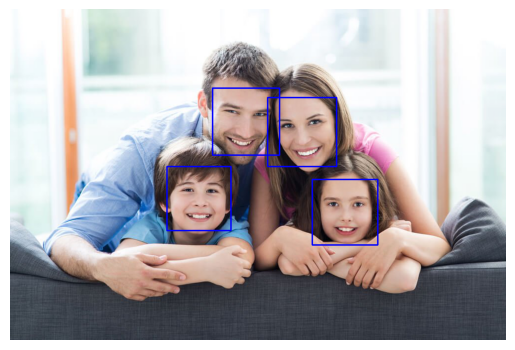

In [12]:
import cv2
import matplotlib.pyplot as plt
import os

# Ruta local al clasificador
cascade_path = 'haarcascade_frontalface_default.xml'
if not os.path.exists(cascade_path):
    raise FileNotFoundError(f'No se encontró el clasificador {cascade_path} en el directorio actual.')

face_cascade = cv2.CascadeClassifier(cascade_path)

# Cargar la imagen
img = cv2.imread('familia.jpg')
if img is None:
    raise FileNotFoundError('La imagen familia.jpg no se encontró en el directorio actual.')

# Convertir a escala de grises
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Detectar rostros
faces = face_cascade.detectMultiScale(gray, 1.3, 5)

# Dibujar los cuadros alrededor de los rostros detectados
for (x, y, w, h) in faces:
    cv2.rectangle(img, (x, y), (x + w, y + h), (255, 0, 0), 2)

# Mostrar la imagen con los rostros detectados
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

El script primero carga un clasificador pre-entrenado de tipo Haar Cascade desde un archivo XML y lee una imagen local verificando su existencia. 

Luego, convierte la imagen al espacio de color de escala de grises para optimizar el procesamiento del algoritmo de deteccion. La funcion principal detectMultiScale escanea la imagen buscando patrones faciales y devuelve una lista de rectangulos definidos por sus coordenadas y dimensiones. 

Finalmente, el codigo recorre estos datos para dibujar rectangulos azules sobre la imagen original y la muestra en pantalla convirtiendo el formato de color para que sea compatible con la visualizacion de la libreria.

### EJERCICIO 2. DETECCIÓN DE OJOS DENTRO DE UN ROSTRO

El siguiente ejercicio nos propone detectar los ojos que hay dentro de un rostro. Para mejorar la precisión y velocidad, no buscaremos ojos en toda la imagen. Primero detectaremos el rostro y definiremos una Región de Interés (ROI) donde limitaremos la búsqueda de los ojos. Se deben de utilizar los ficheros que se adjuntan con el fichero zip para la detección de rostros y ojos.

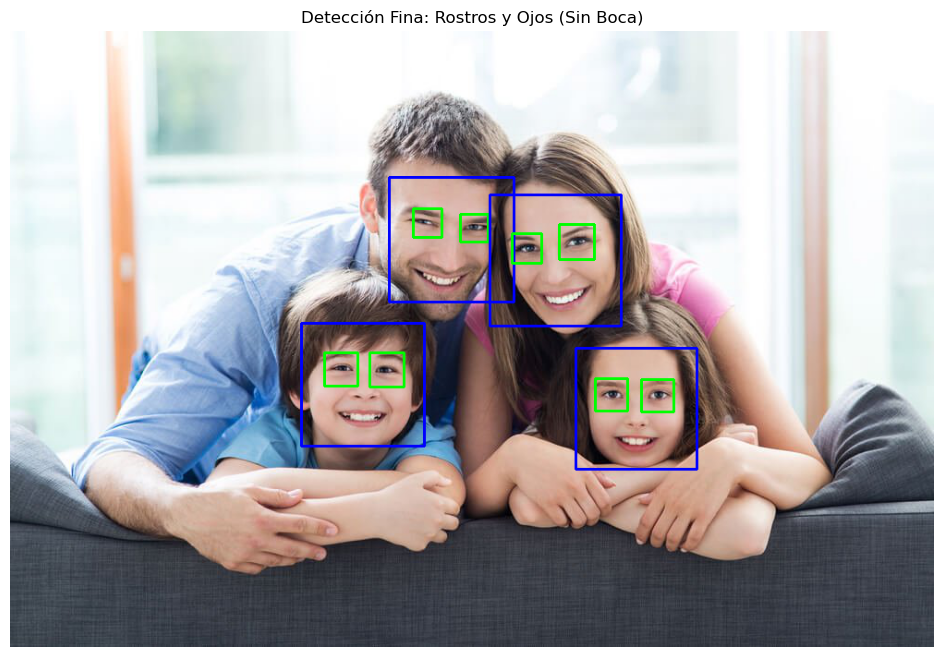

In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

face_cas = cv2.CascadeClassifier('haarcascade_frontalface_default.xml')
eye_cas = cv2.CascadeClassifier('haarcascade_eye.xml')
img = cv2.imread('familia.jpg')
if img is None:
    print("Error: No se pudo cargar la imagen.")
else:
    # Convertir a gris para el procesamiento
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    img_out = img.copy()
    # Detectar Rostros
    faces = face_cas.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5, minSize=(100, 100))
    for (x, y, w, h) in faces:
        # Dibujar rectángulo en el rostro (Azul)
        cv2.rectangle(img_out, (x, y), (x + w, y + h), (255, 0, 0), 2)
        # Definir las Regiones de Interés (ROI)
        roi_gray = gray[y:y + h, x:x + w]
        roi_color = img_out[y:y + h, x:x + w]
        # RESTRICCIÓN PARA EVITAR LA BOCA
        # Cortamos el ROI de la cara para que solo busque en el 60% superior
        alto_ojos = int(h * 0.6)
        zona_ojos_gray = roi_gray[0:alto_ojos, :]
        # Detectar Ojos en la zona restringida
        # minNeighbors=10 es lo bastante estricto para evitar falsos positivos
        eyes = eye_cas.detectMultiScale(zona_ojos_gray, scaleFactor=1.05, minNeighbors=10, minSize=(20, 20))
        for (ex, ey, ew, eh) in eyes:
            cv2.rectangle(roi_color, (ex, ey), (ex + ew, ey + eh), (0, 255, 0), 2)
    plt.figure(figsize=(12, 8))
    plt.imshow(cv2.cvtColor(img_out, cv2.COLOR_BGR2RGB))
    plt.title('Detección Fina: Rostros y Ojos (Sin Boca)')
    plt.axis('off')
    plt.show()

El programa inicializa dos clasificadores en cascada para identificar rostros y ojos, procesando la imagen de entrada en escala de grises para facilitar el analisis. 

Primero utiliza detectMultiScale para localizar caras y, por cada una detectada, extrae una region de interes limitada al sesenta por ciento superior del rostro para optimizar la busqueda de ojos y descartar falsos positivos en el area de la boca. Dentro de esta zona, aplica un segundo filtro de deteccion mas riguroso que marca los ojos con rectangulos verdes, mientras que el contorno facial se resalta en azul. 

El proceso acaba transformando la imagen a color para que la libreria proyecte la imagen final con los rasgos detectados de manera correcta.

### EJERCICIO 3. DETECCIÓN DE SONRISAS

El siguiente ejercicio nos propone detectar la sonrisa dentro de un rostro. El clasificador de sonrisas es más sensible que el de rostros. En este ejercicio implementaremos un detector que identifique si la persona en la imagen está sonriendo, ajustando los parámetros para evitar falsos positivos en los pliegues de la nariz. Los ficheros necesarios para el clasificador se adjuntan con el fichero zip.

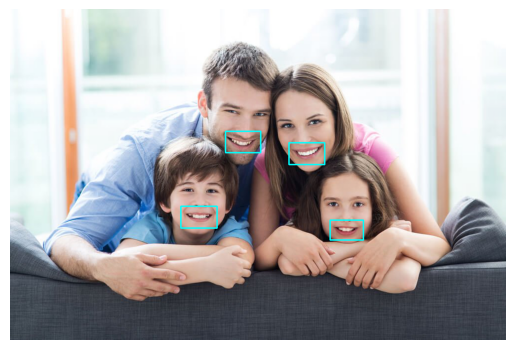

In [17]:
import cv2
import matplotlib.pyplot as plt

face_cas = cv2.CascadeClassifier('haarcascade_frontalface_default.xml')
smile_cas = cv2.CascadeClassifier('haarcascade_mcs_mouth.xml')
img = cv2.imread('familia.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
faces = face_cas.detectMultiScale(gray, 1.3, 5)
for (x, y, w, h) in faces:
    roi_gray = gray[y:y + h, x:x + w]
    # Detectar sonrisas
    smiles = smile_cas.detectMultiScale(roi_gray, 1.1, 20, minSize=(38, 38))
    for (sx, sy, sw, sh) in smiles:
        cv2.rectangle(img[y:y + h, x:x + w], (sx, sy), (sx + sw, sy + sh), (255, 255, 0), 2)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

El script inicializa dos clasificadores en cascada para identificar rostros y bocas, procesando la imagen de entrada en escala de grises para realizar la busqueda de patrones. 

Primero localiza las caras en la escena mediante detectMultiScale y, por cada rostro encontrado, define una región de interés especifica donde aplica el segundo clasificador para detectar sonrisas o bocas. El codigo utiliza parametros de escala y vecindad estrictos para filtrar resultados y dibuja rectangulos de color azul claro directamente sobre los pixeles del area facial detectada utilizando las coordenadas locales del recorte. 

Finalmente, transforma el formato de color para visualizar correctamente la imagen resultante con las detecciones marcadas.

### EJERCICIO 4. DETECCIÓN DE ROSTROS DE PERFIL

En este ejercicio se pide realizar la detección de rostros humanos que se encuentren en la imagen de perfil. No siempre los sujetos miran de frente. OpenCV proporciona un clasificador específico para perfiles (haarcascade profileface). Probaremos su eficacia frente al clasificador frontal estándar. Este fichero no se incluye en el fichero zip y deberán ser buscado por el alumno

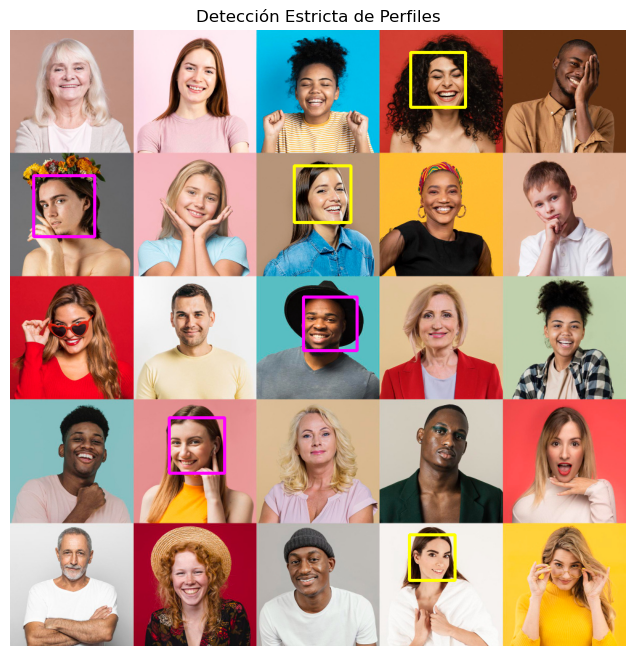

In [32]:
import cv2
import matplotlib.pyplot as plt

profile_cas = cv2.CascadeClassifier('haarcascade_profileface.xml')
img = cv2.imread('caras.jpg')
if img is None:
    print("Error: No se encuentra la imagen.")
else:
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    ancho_img = img.shape[1]
    # Subimos minNeighbors a 15 para ser muy estrictos
    # Definimos minSize para ignorar detalles pequeños como una oreja sola
    params = {
        "scaleFactor": 1.1,
        "minNeighbors": 15,
        "minSize": (50, 50)
    }
    # Detección Normal
    profiles_normal = profile_cas.detectMultiScale(gray, **params)
    # Detección Espejo
    gray_flipped = cv2.flip(gray, 1)
    profiles_flipped = profile_cas.detectMultiScale(gray_flipped, **params)
    for (x, y, w, h) in profiles_normal:
        cv2.rectangle(img, (x, y), (x + w, y + h), (255, 0, 255), 3)
    for (x, y, w, h) in profiles_flipped:
        x_real = ancho_img - x - w
        cv2.rectangle(img, (x_real, y), (x_real + w, y + h), (0, 255, 255), 3)
    plt.figure(figsize=(10, 8))
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title('Detección Estricta de Perfiles')
    plt.axis('off')
    plt.show()

El script inicializa un clasificador de Cascada de Haar diseñado para perfiles faciales y convierte la imagen a escala de grises para asegurar la precision. 

El proceso sigue dos fases: una sobre la imagen original y otra sobre una copia modificada mediante cv2.flip para capturar rostros orientados hacia ambos lados. Para los resultados del modo espejo, el codigo mapea las coordenadas de vuelta al espacio original calculando la posicion real en el eje horizontal antes de dibujar rectangulos de colores rosa y amarillo. 

La ejecucion termina convirtiendo la imagen de BGR a RGB para mostrar el resultado final con los perfiles identificados a traves de la interfaz de Matplotlib.

### EJERCICIO 5. DETECCIÓN DE CUERPOS COMPLETOS (PEATONES)

En este ejercicio se pide a partir de una imagen dada detectar cuerpos humanos completos. Extenderemos el uso de Haar a la detección de figuras humanas completas. Es una técnica común
en sistemas de seguridad para contar personas que pasan por un área determinada.

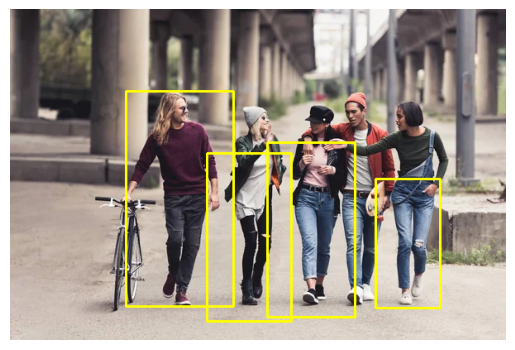

In [58]:
import cv2
import matplotlib.pyplot as plt

body_cas = cv2.CascadeClassifier('haarcascade_fullbody.xml')
img = cv2.imread('personas.jpg')
if img is None:
    print("Error: No se pudo cargar la imagen.")
else:
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    bodies = body_cas.detectMultiScale(gray, 1.1, 3)
    for (x, y, w, h) in bodies:
        cv2.rectangle(img, (x, y), (x + w, y + h), (0, 255, 255), 2)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()

El script carga un clasificador de Casacada de Haar especializado en la deteccion de cuerpos completos. 

Posteriormente, transforma la imagen a escala de grises para reducir la complejidad del procesamiento durante el analisis de patrones. 

La funcion detectMultiScale escanea la matriz en busca de siluetas humanas y genera una lista de coordenadas que definen la ubicacion de cada cuerpo encontrado. El programa recorre estos datos para dibujar rectangulos de color amarillo. 

Finalmente, realiza una conversion de color para que se vea de forma correcta al presentar el resultado.

### EJERCICIO 6. CONTADOR AUTOMÁTICO DE PERSONAS

En este ejercicio se propone a partir de una imagen dada contar las personas detectadas
en la misma. Combinando la detección de cuerpos con una variable contadora, crearemos un
script que analice una imagen o video y nos devuelva el número total de sujetos detectados en
la escena.

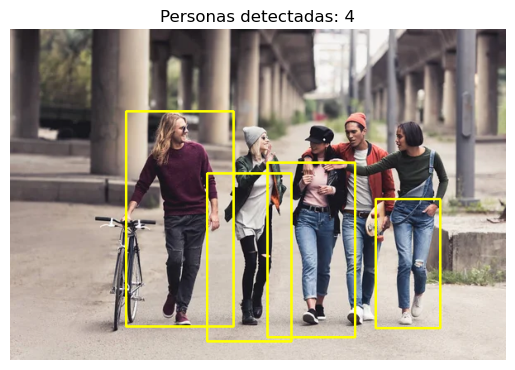

Número total de personas detectadas: 4


In [59]:
import cv2
import matplotlib.pyplot as plt

body_cas = cv2.CascadeClassifier('haarcascade_fullbody.xml')
img = cv2.imread('personas.jpg')
if img is None:
    print("Error: No se pudo cargar la imagen.")
else:
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    bodies = body_cas.detectMultiScale(gray, 1.1, 3)
    contador = 0
    for (x, y, w, h) in bodies:
        cv2.rectangle(img, (x, y), (x + w, y + h), (0, 255, 255), 2)
        contador += 1
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(f'Personas detectadas: {contador}')
    plt.axis('off')
    plt.show()
    print(f'Número total de personas detectadas: {contador}')

El script carga un clasificador Haar Cascade especializado en la identificación de cuerpos completos y procesa la imagen convirtiéndola a escala de grises para optimizar el análisis. 

Luego, localiza las siluetas humanas presentes en la escena y, mediante un bucle, recorre cada detección para dibujar rectángulos amarillos sobre la imagen original mientras incrementa una variable de conteo. 

Finalmente, el código transforma la imagen de BGR a RGB para se vea correctamente e imprime un encabezado y un mensaje en consola que informan el número total de personas contabilizadas.

### EJERCICIO 7. DIFUMINADO AUTOMATICO DE ROSTROS

En este ejercicio se propone a partir de una imagen dada difuminar el rostro de personas. Una aplicación ética de las cascadas de Haar es el anonimato. Detectaremos los rostros y aplicaremos un filtro Gaussiano intenso o un efecto de pixelado únicamente en el área detectada.

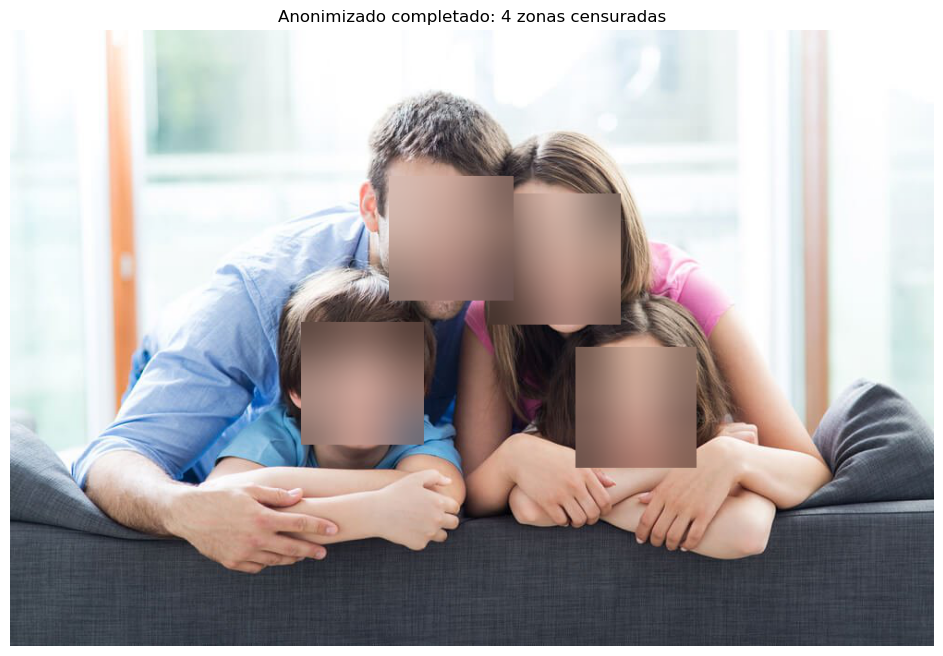

In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img_path = 'familia.jpg'
img = cv2.imread(img_path)

face_cas = cv2.CascadeClassifier('haarcascade_frontalface_default.xml')
profile_cas = cv2.CascadeClassifier('haarcascade_profileface.xml')

if img is None:
    print(f"Error: No se encuentra la imagen {img_path}")
else:
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    # Detección Frontal
    rostros = list(face_cas.detectMultiScale(gray, 1.1, 10, minSize=(80, 80)))
    # Detección Perfil (Normal)
    perfiles = list(profile_cas.detectMultiScale(gray, 1.1, 10, minSize=(80, 80)))
    # Detección Perfil (Espejo)
    gray_flipped = cv2.flip(gray, 1)
    perfiles_flipped = list(profile_cas.detectMultiScale(gray_flipped, 1.1, 10, minSize=(80, 80)))
    # Ajustar coordenadas de los perfiles invertidos y añadirlos a la lista
    ancho_img = img.shape[1]
    for (x, y, w, h) in perfiles_flipped:
        x_real = ancho_img - x - w
        rostros.append((x_real, y, w, h))
    # Añadir los perfiles normales a la lista principal
    for rect in perfiles:
        rostros.append(rect)
    # ANONIMIZADO (Blur)
    img_anonima = img.copy()
    for (x, y, w, h) in rostros:
        # Extraer la región de interés (ROI) -> La cara
        roi_cara = img_anonima[y:y+h, x:x+w]
        # Aplicar desenfoque Gaussiano fuerte
        roi_blur = cv2.GaussianBlur(roi_cara, (99, 99), 30)
        # Pegar la cara borrosa sobre la imagen original
        img_anonima[y:y+h, x:x+w] = roi_blur
    plt.figure(figsize=(12, 8))
    plt.imshow(cv2.cvtColor(img_anonima, cv2.COLOR_BGR2RGB))
    plt.title(f'Anonimizado completado: {len(rostros)} zonas censuradas')
    plt.axis('off')
    plt.show()

El script implementa un sistema de anonimizado automático combinando clasificadores de rostros frontales y de perfil sobre una imagen cargada en escala de grises. 

El proceso ejecuta tres detecciones simultáneas: una para caras de frente, otra para perfiles naturales y una tercera sobre una versión volteada de la imagen para capturar perfiles orientados en sentido opuesto, unificando todas las coordenadas en una única lista. 

Para cada región detectada, el código extrae el área de interés y le aplica un filtro de desenfoque gaussiano de alta intensidad, sustituyendo los píxeles originales por la versión difuminada para ocultar la identidad. 

Finalmente, transforma la matriz resultante de BGR a RGB y utiliza la librería Matplotlib para proyectar la imagen censurada, indicando en el título la cantidad total de zonas que han sido procesadas.

### EJERCICIO 8. DETECCIÓN DE ROSTROS EN TIEMPO REAL CON WEBCAM

En este ejercicio se nos pide detectar un rostro en tiempo real en un flujo de vídeo. En este ejercicio optimizaremos el código para que el procesamiento de cada fotograma permita una visualización fluida sin retardos.

In [18]:
import cv2

# Si la celda se relanza, intentamos cerrar ventanas anteriores
cv2.destroyAllWindows()

face_cas = cv2.CascadeClassifier('haarcascade_frontalface_default.xml')
profile_cas = cv2.CascadeClassifier('haarcascade_profileface.xml')

if face_cas.empty() or profile_cas.empty():
    print("Error: no se pudieron cargar los clasificadores Haar.")
else:
    # CAP_DSHOW mejora estabilidad en Windows/Jupyter
    cap = cv2.VideoCapture(0, cv2.CAP_DSHOW)
    if not cap.isOpened():
        print("Error al iniciar cámara")
    else:
        window_name = "Deteccion de rostros en tiempo real"
        cv2.namedWindow(window_name, cv2.WINDOW_NORMAL)
        try:
            while True:
                ret, frame = cap.read()
                if not ret:
                    break

                gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

                # Rostros frontales
                rostros = list(face_cas.detectMultiScale(
                    gray, scaleFactor=1.1, minNeighbors=5, minSize=(40, 40)
                ))

                # Rostros de perfil (normal + espejo)
                perfiles = list(profile_cas.detectMultiScale(
                    gray, scaleFactor=1.1, minNeighbors=5, minSize=(40, 40)
                ))
                gray_flipped = cv2.flip(gray, 1)
                perfiles_flipped = list(profile_cas.detectMultiScale(
                    gray_flipped, scaleFactor=1.1, minNeighbors=5, minSize=(40, 40)
                ))

                ancho_img = frame.shape[1]

                for (x, y, w, h) in rostros:
                    cv2.rectangle(frame, (x, y), (x + w, y + h), (255, 0, 0), 2)
                for (x, y, w, h) in perfiles:
                    cv2.rectangle(frame, (x, y), (x + w, y + h), (255, 0, 255), 2)
                for (x, y, w, h) in perfiles_flipped:
                    x_real = ancho_img - x - w
                    cv2.rectangle(frame, (x_real, y), (x_real + w, y + h), (0, 255, 255), 2)

                total = len(rostros) + len(perfiles) + len(perfiles_flipped)
                cv2.putText(
                    frame,
                    f'Rostros detectados: {total}',
                    (10, 30),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.9,
                    (0, 255, 0),
                    2
                )

                cv2.imshow(window_name, frame)

                key = cv2.waitKey(1) & 0xFF
                if key == ord('q') or key == 27:
                    break

                # Si cierras la ventana con la X, salimos también
                if cv2.getWindowProperty(window_name, cv2.WND_PROP_VISIBLE) < 1:
                    break
        except KeyboardInterrupt:
            print("Detenido por el usuario.")
        finally:
            cap.release()
            cv2.destroyAllWindows()
            cv2.waitKey(1)

El programa inicializa un sistema de videovigilancia en tiempo real que utiliza la cámara web para detectar y contabilizar rostros frontales y de perfil simultáneamente. 

Tras cargar los clasificadores Haar Cascade y configurar la captura de video, el código ejecuta un bucle infinito donde procesa cada cuadro convirtiéndolo a escala de grises y analizando tres variantes: vista frontal, perfil natural y perfil espejado mediante la inversión de la imagen. 

Los resultados se dibujan sobre el flujo de video en vivo utilizando rectángulos de distintos colores y se añade un contador textual en la parte superior de la ventana.

### EJERCICIO 9. DETECCIÓN DE MATRÍCULAS DE COCHES

En este ejercicio debemos de obtener las matrículas de unos coches de una foto donde hay más vehículos. Aunque las matrículas suelen requerir OCR, las cascadas de Haar pueden localizarlas rápido en una imagen de tráfico.

Clasificador cargado desde: haarcascade_russian_plate_number.xml


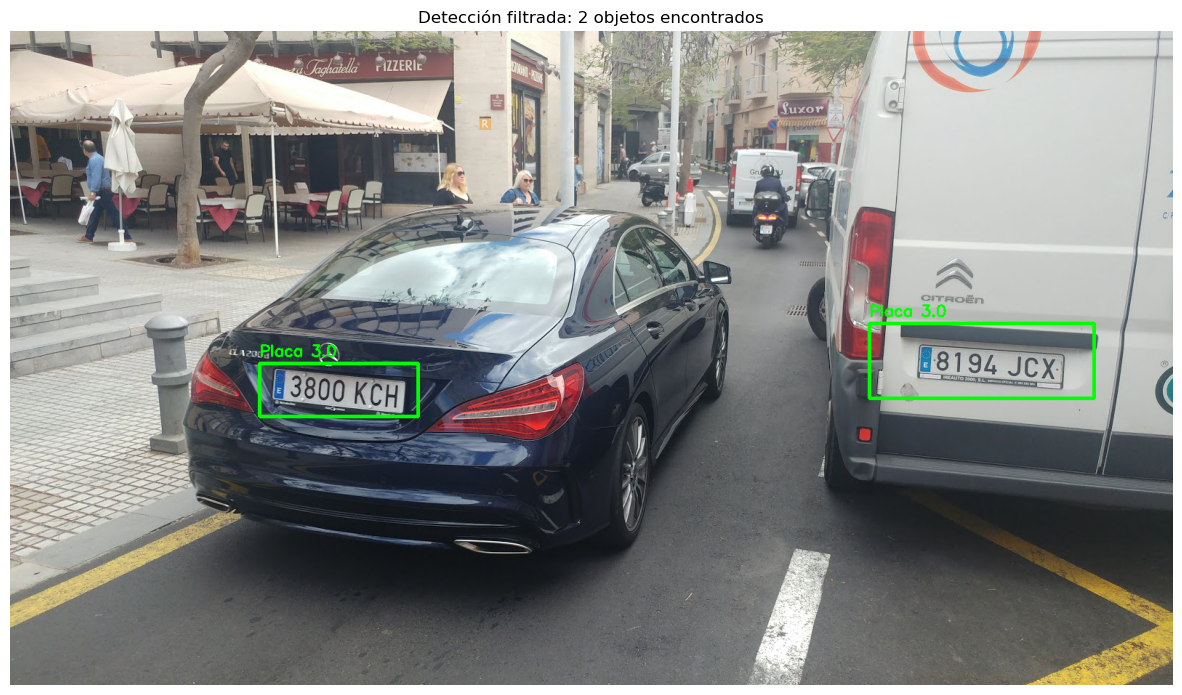

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

img = cv2.imread('coches.jpg')

plate_cascade = cv2.CascadeClassifier('haarcascade_russian_plate_number.xml')

if img is None:
    print('Error: No se encuentra la imagen coches.jpg.')
elif plate_cascade.empty():
    print('Error: No se pudo cargar el clasificador de matrículas.')
else:
    print(f'Clasificador cargado desde: {loaded_path}')
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Detección inicial
    # Subimos minNeighbors para ser más exigentes con el patrón de texto
    raw_plates = plate_cascade.detectMultiScale(
        gray, scaleFactor=1.1, minNeighbors=12, minSize=(50, 20)
    )

    img_res = img.copy()
    count = 0

    # Filtrado por Aspect Ratio (Proporción)
    for (x, y, w, h) in raw_plates:
        aspect_ratio = w / float(h)

        # Una matrícula suele tener un ratio entre 2.5 y 5.5
        if 2.5 < aspect_ratio < 5.5:
            cv2.rectangle(img_res, (x, y), (x + w, y + h), (0, 255, 0), 3)
            cv2.putText(
                img_res,
                f'Placa {aspect_ratio:.1f}',
                (x, y - 10),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.7,
                (0, 255, 0),
                2
            )
            count += 1

    plt.figure(figsize=(15, 10))
    plt.imshow(cv2.cvtColor(img_res, cv2.COLOR_BGR2RGB))
    plt.title(f'Detección filtrada: {count} objetos encontrados')
    plt.axis('off')
    plt.show()

El programa implementa un sistema de localización de matrículas de vehiculos que utiliza un clasificador Haar Cascade especializado en estas placas. 

Primero, el código convierte la imagen a escala de grises para realizar una detección inicial, configurada con parámetros estrictos de vecindad y tamaño mínimo para reducir el ruido. Se implementa un filtro de proporción geométrica, donde calcula la relación entre el ancho y el alto de cada objeto detectado para descartar cualquier figura que no se ajuste al rango rectangular típico de una matrícula. 

Finalmente, el código dibuja rectángulos verdes sobre las detecciones válidas, etiqueta cada una con su valor de proporción, y proyecta la imagen resultante en formato RGB indicando el número total de placas confirmadas.